# Pesos Espaciales (*Spatial Weights*)

**Adaptado de:** Rey, Arribas-Bel & Wolf – *Geographic Data Science with Python*, Capítulo 4. 


# 1. Introducción

Los **pesos espaciales** (*spatial weights*) son la forma estándar de representar **grafos geográficos** en ciencia de datos espaciales y estadística espacial. Son estructuras que codifican las **relaciones geográficas** entre las unidades observacionales de un conjunto de datos georreferenciado.

### ¿Por qué nos interesan?

- Son **matrices dispersas** (*sparse matrices*) → estructuras de datos eficientes.
- Se modelan como **grafos** → se les pueden aplicar algoritmos de teoría de grafos.
- Son la base de análisis avanzados: autocorrelación espacial, regresión espacial, clustering geográfico, etc.

### Preguntas espaciales típicas

> *¿Qué barrios te rodean?*  
> *¿Cuántas bombas de bencina hay a menos de 5 km de mi auto?*

Para usar esta información en análisis estadístico, necesitamos calcular estas relaciones **entre todos los pares de observaciones**, construyendo una **topología** (estructura matemática de conectividad). Las matrices de pesos espaciales representan esa topología.


In [1]:
# Importar librerías necesarias
import geopandas
import pandas
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from libpysal import weights
from libpysal import cg as geometry

# Para mapas base (opcional, descomentar si está instalado)
# import contextily

# Para superficies raster (opcional)
# import rioxarray

import seaborn


# 2. Pesos de contigüidad

Dos objetos espaciales son **contiguos** si comparten una frontera común. Parece simple, pero hay matices: existen diferentes formas de "compartir frontera".

Usaremos la analogía con piezas de **ajedrez**:

| Tipo | Regla | Análogo en ajedrez |
|------|-------|-------------------|
| **Rook** (torre) | Comparten una **arista** completa | Movimiento horizontal/vertical |
| **Queen** (reina) | Comparten al menos un **vértice** (incluye aristas) | Movimiento en cualquier dirección |
| **Bishop** (alfil) | Comparten sólo un **vértice** (sin arista compartida) | Movimiento diagonal |

Empecemos creando una grilla regular de 3×3 para visualizar estos conceptos:


**¿De dónde vienen estos nombres?**

La terminología Rook/Queen/Bishop proviene de la literatura de análisis espacial de los años 1970–80, donde se buscaba una forma intuitiva de describir tipos de adyacencia en grillas regulares. Como los movimientos de las piezas de ajedrez coinciden exactamente con los patrones de vecindad en una cuadrícula, la analogía se adoptó como convención y hoy es el estándar en todas las herramientas de análisis espacial: PySAL (Python), spdep (R), GeoDa, etc.

**Vamos a crear un tablero**

In [2]:

from shapely.geometry import Polygon
#vamos a crear un polígono cuadrado de 1x1 unidades
cuadrado = Polygon([(0, 0), (1, 0), (1, 1), (0, 1)])

```
(0,1) -------- (1,1)
  |              |
  |   cuadrado   |
  |              |
(0,0) -------- (1,0)
```

In [3]:
# Ahora vamos a crear varios polígonos cuadrados en una grilla de 3×3, es decir, 9 polígonos en total
# Lista vacía donde guardaremos los polígonos
polys = []

# Recorremos cada posición (x, y) de la grilla 3×3
for y in range(3):        # y = 0, 1, 2
    for x in range(3):    # x = 0, 1, 2
        # Creamos un cuadrado con 4 esquinas
        cuadrado = Polygon([
            (x,     y),      # esquina inferior-izquierda
            (x + 1, y),      # esquina inferior-derecha
            (x + 1, y + 1),  # esquina superior-derecha
            (x,     y + 1),  # esquina superior-izquierda
        ])
        polys.append(cuadrado)

# Convertimos a GeoDataFrame
gdf = geopandas.GeoDataFrame({
    "geometry": polys,
    "id": [f"P-{str(i).zfill(2)}" for i in range(len(polys))],
})
gdf.head()

,geometry,id
0,"POLYGON ((0.00000 0.00000, 1.00000 0.00000, 1....",P-00
1,"POLYGON ((1.00000 0.00000, 2.00000 0.00000, 2....",P-01
2,"POLYGON ((2.00000 0.00000, 3.00000 0.00000, 3....",P-02
3,"POLYGON ((0.00000 1.00000, 1.00000 1.00000, 1....",P-03
4,"POLYGON ((1.00000 1.00000, 2.00000 1.00000, 2....",P-04


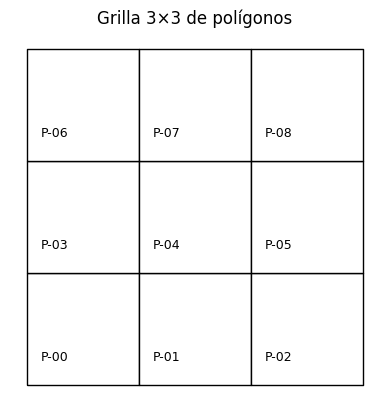

In [4]:
# Visualizar la grilla con etiquetas
# gdf es un geodataframe y 
# plot es un método de geopandas para visualizarlo
ax = gdf.plot(facecolor="w", edgecolor="k")
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    gdf["id"],
):
    plt.text(x, y, t, va="center", ha="center", fontsize=9)
ax.set_axis_off()
ax.set_title("Grilla 3×3 de polígonos", fontsize=12)
plt.show()

### 2.0.1 Contigüidad Rook (torre)

La contigüidad **Rook** requiere que dos polígonos compartan una **arista** completa. Así, P-00 es vecino Rook de P-01 y P-03, pero **no** de P-04 (sólo comparten un vértice).


In [5]:
# Construir la matriz de contigüidad Rook
wr = weights.contiguity.Rook.from_dataframe(gdf)

wr

/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_11927/227271147.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wr = weights.contiguity.Rook.from_dataframe(gdf)


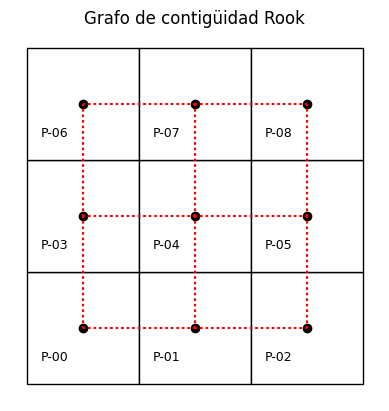

In [6]:
# Visualizar el grafo de vecindad Rook
f, ax = plt.subplots(1, 1, subplot_kw=dict(aspect="equal"))

gdf.plot(facecolor="w", edgecolor="k", ax=ax)

for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    gdf["id"],
):
    plt.text(x, y, t, va="center", ha="center", fontsize=9)
    
wr.plot(gdf, edge_kws=dict(color="r", linestyle=":"), ax=ax)
ax.set_axis_off()
ax.set_title("Grafo de contigüidad Rook", fontsize=12)
plt.show()


 Cada línea roja dice: "estos dos polígonos son contiguos, es decir, se tocan físicamente

In [7]:
# Diccionario de vecinos
wr.neighbors


{0: [1, 3],
 1: [0, 2, 4],
 2: [1, 5],
 3: [0, 4, 6],
 4: [1, 3, 5, 7],
 5: [8, 2, 4],
 6: [3, 7],
 7: [8, 4, 6],
 8: [5, 7]}


El atributo `neighbors` es un diccionario que guarda todas las relaciones de contigüidad. Para cada polígono, te dice con cuáles otros se toca.

Este diccionario explota la **naturaleza dispersa** de la matriz: sólo almacena los pares con peso no nulo.

Podemos también construir la **representación densa** (la matriz completa):


In [8]:
# Representación matricial densa (para inspección, no recomendada para datos grandes)
pandas.DataFrame(*wr.full()).astype(int)


,0,1,2,3,4,5,6,7,8
0,0,1,0,1,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0
2,0,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,1,0,0
4,0,1,0,1,0,1,0,1,0
5,0,0,1,0,1,0,0,0,1
6,0,0,0,1,0,0,0,1,0
7,0,0,0,0,1,0,1,0,1
8,0,0,0,0,0,1,0,1,0


Es exactamente la misma información que wr.neighbors pero en formato tabla. Si cruzas la fila 0 con la columna 1 y ves un 1, significa que el polígono 0 y el 1 son contiguos. Si ves un 0, no se tocan.

### 2.0.2 Contigüidad Queen (reina)

La contigüidad **Queen** es más inclusiva: basta compartir un **vértice**. Esto agrega, por ejemplo, a P-04 como vecino de P-00 (comparten la esquina superior derecha de P-00).


/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_11927/1415673762.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(gdf)


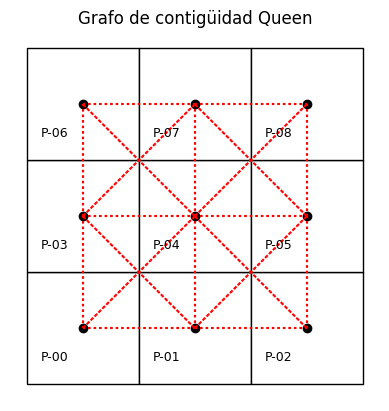

In [9]:
# Construir la matriz de contigüidad Queen
wq = weights.contiguity.Queen.from_dataframe(gdf)

# Visualizar
f, ax = plt.subplots(1, 1, subplot_kw=dict(aspect="equal"))
gdf.plot(facecolor="w", edgecolor="k", ax=ax)
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    gdf["id"],
):
    plt.text(x, y, t, va="center", ha="center", fontsize=9)
wq.plot(gdf, edge_kws=dict(color="r", linestyle=":"), ax=ax)
ax.set_axis_off()
ax.set_title("Grafo de contigüidad Queen", fontsize=12)
plt.show()


In [10]:
# Vecinos Queen
wq.neighbors


{0: [1, 3, 4],
 1: [0, 2, 3, 4, 5],
 2: [1, 4, 5],
 3: [0, 1, 4, 6, 7],
 4: [0, 1, 2, 3, 5, 6, 7, 8],
 5: [1, 2, 4, 7, 8],
 6: [3, 4, 7],
 7: [3, 4, 5, 6, 8],
 8: [4, 5, 7]}

In [11]:
# Pesos asociados a cada par (binario para contigüidad)
wq.weights


{0: [1.0, 1.0, 1.0],
 1: [1.0, 1.0, 1.0, 1.0, 1.0],
 2: [1.0, 1.0, 1.0],
 3: [1.0, 1.0, 1.0, 1.0, 1.0],
 4: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 5: [1.0, 1.0, 1.0, 1.0, 1.0],
 6: [1.0, 1.0, 1.0],
 7: [1.0, 1.0, 1.0, 1.0, 1.0],
 8: [1.0, 1.0, 1.0]}

Por defecto todos valen 1 (contigüidad binaria: se tocan o no se tocan).

### Atributos clave del objeto `W`

Los objetos de pesos espaciales de `pysal` incluyen atributos útiles:

- **`cardinalities`**: número de vecinos por observación.
- **`histogram`**: distribución de cardinalidades.
- **`pct_nonzero`**: densidad de la matriz (% de entradas no nulas).
- **`s0`**: número total de joins (aristas en el grafo).


**Cardinalidad**

In [12]:
# Cardinalidades: cuántos vecinos tiene cada polígono
wq.cardinalities

# {0: 3, 1: 5, 2: 3, 3: 5, 4: 8, 5: 5, 6: 3, 7: 5, 8: 3}
# P-00 tiene 3 vecinos (esquina)
# P-04 tiene 8 vecinos (centro, toca a todos)

{0: 3, 1: 5, 2: 3, 3: 5, 4: 8, 5: 5, 6: 3, 7: 5, 8: 3}

**Histograma**

Cuantos polígonos tienen X vecinos

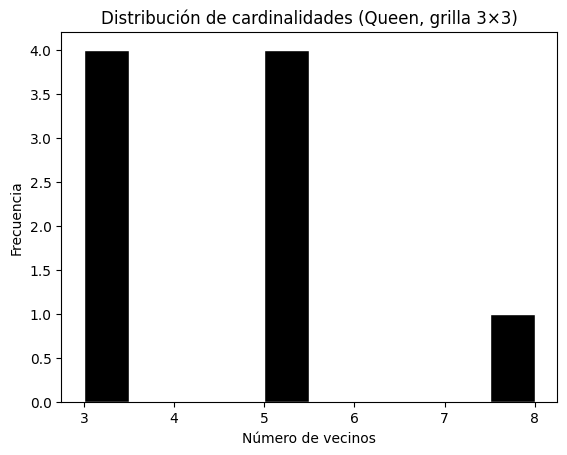

In [13]:
# Visualizar la distribución de cardinalidades
pandas.Series(wq.cardinalities).plot.hist(color="k", edgecolor="w")
plt.xlabel("Número de vecinos")
plt.ylabel("Frecuencia")
plt.title("Distribución de cardinalidades (Queen, grilla 3×3)")
plt.show()


In [14]:
# Histograma
wq.histogram

# [(3, 4), (5, 4), (8, 1)]
# 4 polígonos tienen 3 vecinos (las 4 esquinas)
# 4 polígonos tienen 5 vecinos (los 4 bordes)
# 1 polígono tiene 8 vecinos (el centro)

[(np.int64(3), np.int64(4)),
 (np.int64(4), np.int64(0)),
 (np.int64(5), np.int64(4)),
 (np.int64(6), np.int64(0)),
 (np.int64(7), np.int64(0)),
 (np.int64(8), np.int64(1))]

In [15]:
# pct_nonzero: qué tan "llena" está la matriz
wq.pct_nonzero

# 49.38
# Casi la mitad de la matriz tiene valores distintos de cero
# En una grilla chica como esta hay muchas conexiones
# En datos reales con miles de polígonos, este valor suele ser muy bajo (1-5%)

49.382716049382715

#### Conexión con teoría de grafos

Una matriz de pesos espaciales es esencialmente una **matriz de adyacencia** de un grafo ponderado:

- Cada **observación** = un **nodo**.
- Cada **peso no nulo** $w_{ij}$ = una **arista** entre $i$ y $j$.
- A veces se le llama **grafo dual** de los datos geográficos.

> **Diferencia clave con series temporales:** las relaciones espaciales son **bidireccionales** (si A es vecino de B, B es vecino de A), mientras que las temporales son unidireccionales.


## 2.1 Pesos desde tablas geográficas reales

Ahora pasemos de la grilla artificial a datos reales. Usaremos los **tracts censales de San Diego, California**.

> Los formatos espaciales comunes (shapefiles, GeoPackage, etc.) **no almacenan topología** explícitamente; sólo definen polígonos como secuencias de vértices. `pysal` usa **índices espaciales** eficientes internamente para extraer las relaciones de vecindad.


In [16]:
# Leer datos de tracts de San Diego
san_diego_tracts = geopandas.read_file("datos/external/sandiego/sandiego_tracts.gpkg"
)


san_diego_tracts.head()

,GEOID,median_age,total_pop,total_pop_white,tt_work,hh_total,hh_female,total_bachelor,median_hh_income,income_gini,...,state,county,tract,area_sqm,pct_rented,pct_hh_female,pct_bachelor,pct_white,sub_30,geometry
0,06073018300,37.1,2590.0,2375.0,1299.0,2590.0,137.0,0.0,62500.0,0.5355,...,06,073,018300,2.876449,0.373913,0.052896,0.000000,0.916988,False,"POLYGON ((-13069450.120 3922380.770, -13069175..."
1,06073018601,41.2,5147.0,4069.0,1970.0,5147.0,562.0,24.0,88165.0,0.4265,...,06,073,018601,4.548797,0.205144,0.109190,0.004663,0.790558,False,"POLYGON ((-13067719.770 3922939.420, -13067631..."
2,06073017601,54.4,5595.0,4925.0,1702.0,5595.0,442.0,34.0,110804.0,0.4985,...,06,073,017601,8.726275,0.279029,0.078999,0.006077,0.880250,False,"POLYGON ((-13058166.110 3907247.690, -13058140..."
3,06073019301,42.3,7026.0,5625.0,3390.0,7026.0,638.0,46.0,100539.0,0.4003,...,06,073,019301,3.519743,0.196512,0.090806,0.006547,0.800598,False,"POLYGON ((-13056896.290 3925255.610, -13056868..."
4,06073018700,21.8,40402.0,30455.0,24143.0,40402.0,2456.0,23.0,41709.0,0.3196,...,06,073,018700,559.150793,0.949887,0.060789,0.000569,0.753799,False,"POLYGON ((-13090788.510 3946435.430, -13090736..."


/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_11927/3641587720.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = weights.contiguity.Queen.from_dataframe(san_diego_tracts)
/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_11927/3641587720.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_rook = weights.contiguity.Rook.from_dataframe(san_diego_tracts)


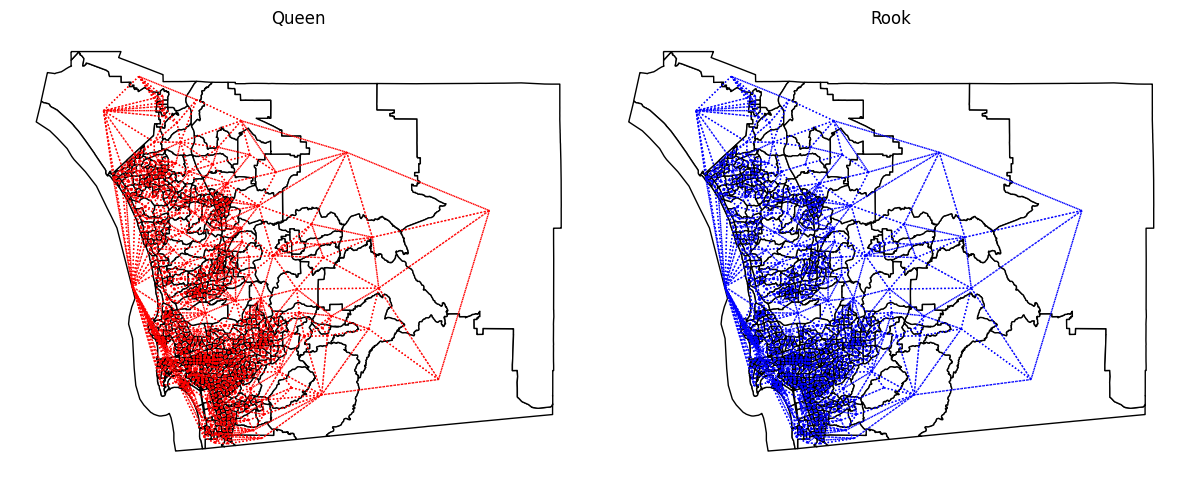

In [17]:
w_queen = weights.contiguity.Queen.from_dataframe(san_diego_tracts)
w_rook = weights.contiguity.Rook.from_dataframe(san_diego_tracts)

# Visualizar: Queen izquierda, Rook derecha
f, axs = plt.subplots(1, 2, figsize=(12, 6))

# Queen
san_diego_tracts.plot(edgecolor="k", facecolor="w", ax=axs[0])
w_queen.plot(
    san_diego_tracts,
    ax=axs[0],
    edge_kws=dict(color="r", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
axs[0].set_axis_off()
axs[0].set_title("Queen")

# Rook
san_diego_tracts.plot(edgecolor="k", facecolor="w", ax=axs[1])
w_rook.plot(
    san_diego_tracts,
    ax=axs[1],
    edge_kws=dict(color="b", linestyle=":", linewidth=1),
    node_kws=dict(marker=""),
)
axs[1].set_axis_off()
axs[1].set_title("Rook")

plt.tight_layout()
plt.show()

In [18]:
# Propiedades del grafo
print(f"Número de unidades espaciales (n): {w_queen.n}")
print(f"Densidad de la matriz w_queen: {w_queen.pct_nonzero:.4f}%")
print(f"Densidad de la matriz w_rook: {w_rook.pct_nonzero:.4f}%")

Número de unidades espaciales (n): 628
Densidad de la matriz w_queen: 1.0183%
Densidad de la matriz w_rook: 0.8722%


Observemos que la matriz es **mucho más dispersa** que en la grilla 3×3. Esto es típico de datos reales: la mayoría de los polígonos no son vecinos entre sí.


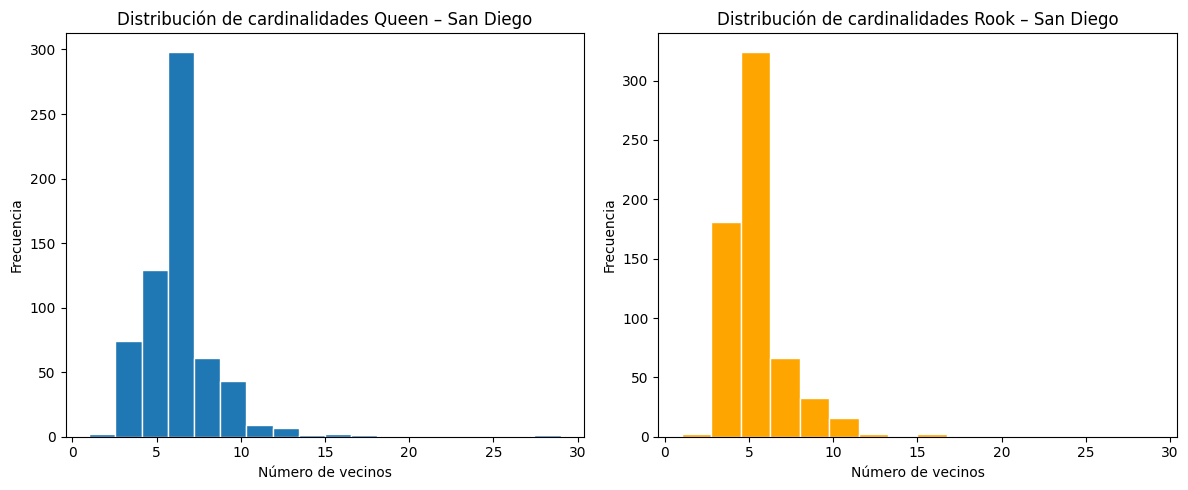

In [19]:
# Distribución de cardinalidades Queen y Rook para San Diego
s_queen = pandas.Series(w_queen.cardinalities)
s_rook = pandas.Series(w_rook.cardinalities)

f, axs = plt.subplots(1, 2, figsize=(12, 5))

# Queen
s_queen.plot.hist(bins=s_queen.unique().shape[0], edgecolor="w", ax=axs[0])
axs[0].set_xlabel("Número de vecinos")
axs[0].set_ylabel("Frecuencia")
axs[0].set_title("Distribución de cardinalidades Queen – San Diego")

# Rook
s_rook.plot.hist(bins=s_rook.unique().shape[0], edgecolor="w", ax=axs[1], color="orange")
axs[1].set_xlabel("Número de vecinos")
axs[1].set_ylabel("Frecuencia")
axs[1].set_title("Distribución de cardinalidades Rook – San Diego")

plt.tight_layout()
plt.show()


La distribución Rook se desplaza ligeramente a la izquierda respecto a Queen. Esto tiene sentido: **todo vecino Rook es también vecino Queen**, pero no todo vecino Queen es Rook (algunos sólo comparten un vértice).


## 2.2 Pesos desde superficies (rasters)

Desde la versión 2.4, `pysal` permite construir pesos espaciales a partir de objetos `xarray.DataArray` (datos raster). Esto amplía los análisis que tradicionalmente se usaban sólo para tablas geográficas.
El objeto resultante es de tipo `WSP` (versión dispersa del objeto `W`).


In [20]:
import rioxarray
# Ejemplo
sao_paulo = rioxarray.open_rasterio("datos/external/ghsl/ghsl_sao_paulo.tif")
w_sao_paulo = weights.contiguity.Queen.from_xarray(sao_paulo)


In [21]:
w_sao_paulo

In [22]:
# Número de píxeles
print(w_sao_paulo.n)

# Ver la matriz dispersa
#print(w_sao_paulo.sparse)

# Convertir a W normal si quieres usar .neighbors, .weights, etc.
w_dense = w_sao_paulo.to_W()


97232


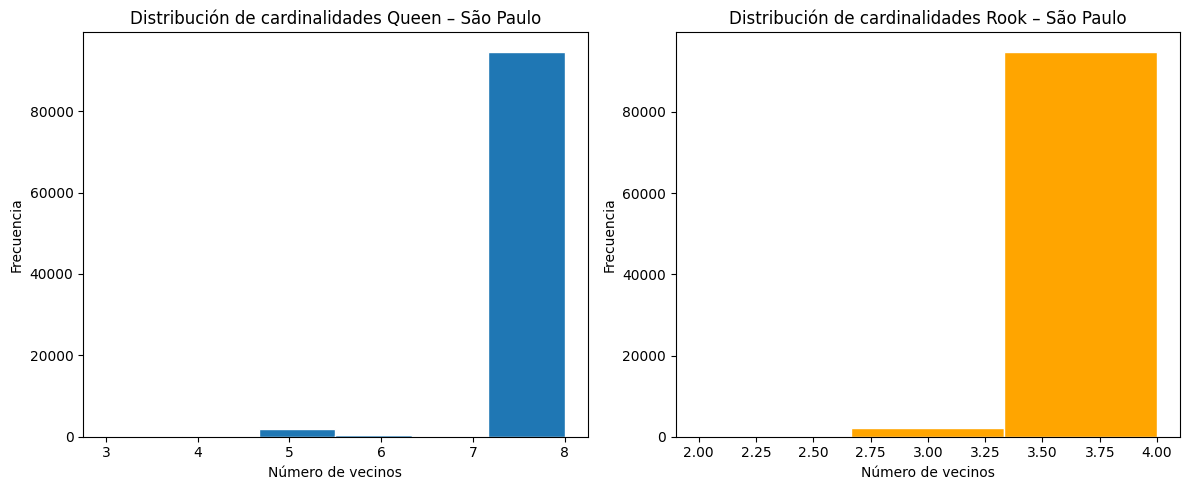

In [23]:
# Cargar raster
sao_paulo = rioxarray.open_rasterio("datos/external/ghsl/ghsl_sao_paulo.tif")

# Construir pesos y convertir WSP -> W
w_queen_sp = weights.contiguity.Queen.from_xarray(sao_paulo).to_W()
w_rook_sp = weights.contiguity.Rook.from_xarray(sao_paulo).to_W()

# Distribución de cardinalidades
s_queen_sp = pandas.Series(w_queen_sp.cardinalities)
s_rook_sp = pandas.Series(w_rook_sp.cardinalities)

f, axs = plt.subplots(1, 2, figsize=(12, 5))

# Queen
s_queen_sp.plot.hist(bins=s_queen_sp.unique().shape[0], edgecolor="w", ax=axs[0])
axs[0].set_xlabel("Número de vecinos")
axs[0].set_ylabel("Frecuencia")
axs[0].set_title("Distribución de cardinalidades Queen – São Paulo")

# Rook
s_rook_sp.plot.hist(bins=s_rook_sp.unique().shape[0], edgecolor="w", ax=axs[1], color="orange")
axs[1].set_xlabel("Número de vecinos")
axs[1].set_ylabel("Frecuencia")
axs[1].set_title("Distribución de cardinalidades Rook – São Paulo")

plt.tight_layout()
plt.show()

## Distribución de cardinalidades – São Paulo (Raster)

A diferencia de los polígonos irregulares, un raster tiene una estructura espacial
implícita definida por la posición de cada celda en la grilla. Por ello, la distribución
de vecinos es casi determinista:

- **Queen** asigna hasta **8 vecinos** por celda (lados + esquinas). La gran mayoría
  de las celdas interiores tienen exactamente 8, y solo las celdas en los bordes
  del raster presentan valores menores (5 o 3).

- **Rook** asigna hasta **4 vecinos** por celda (solo lados). De forma análoga,
  las celdas interiores tienen exactamente 4 y las de borde menos.

La diferencia entre ambos criterios es mucho más marcada que en polígonos irregulares:
Queen duplica aproximadamente el número de vecinos respecto a Rook, reflejando
claramente que en una grilla regular **todo vecino Rook es también vecino Queen**,
pero no al revés.

## ¿Qué hacer con la geometría del raster?

Construir un polígono por cada píxel no es práctico: un raster de alta resolución
como el GHSL de São Paulo puede tener millones de celdas, lo que hace inviable
tanto el almacenamiento como el procesamiento.

La alternativa con mayor sentido geográfico es **agregar los píxeles en unidades
espaciales significativas**, como zonas censales, municipios o grillas regulares
de mayor resolución. De esta forma:

- Cada unidad espacial **resume** la información de los píxeles que contiene
  (promedio, suma, moda, etc.).
- La vecindad entre unidades tiene un **significado real** en el territorio.

En resumen, el raster es una fuente de datos, pero para construir pesos espaciales
con sentido es preferible unirlo con una geometría de referencia que defina
las unidades de análisis.

# 3. Pesos basados en distancia

Hasta ahora hemos definido vecindad por **contigüidad**: dos unidades son vecinas
si comparten un lado o un vértice. Sin embargo, este criterio puede no ser adecuado
cuando las unidades espaciales son muy irregulares en tamaño o forma.

Una alternativa es definir vecindad en función de la **distancia** entre unidades.
La idea es simple: unidades más cercanas entre sí tienen una relación espacial más
fuerte que unidades lejanas. Para implementar esto se necesitan dos ingredientes:

1. Una **matriz de distancias** entre todos los pares de observaciones.
2. Una **función** que transforme esas distancias en pesos.

Para polígonos como los tracts de San Diego, la distancia se calcula entre
**centroides**, es decir, el punto central de cada polígono.

---

## 3.1 K vecinos más cercanos (KNN)

KNN es el enfoque más simple: los vecinos de una unidad son simplemente sus
**k unidades más cercanas**, independientemente de la distancia absoluta.

Algunas propiedades importantes:

- **Siempre asigna exactamente k vecinos** a cada unidad, lo que garantiza que
  ninguna observación quede aislada (sin vecinos).
- Es útil cuando las unidades tienen **tamaños muy distintos**, ya que la
  contigüidad podría dejar sin vecinos a unidades pequeñas rodeadas de pocas
  unidades grandes.
- La elección de **k** es una decisión: valores pequeños capturan
  relaciones muy locales, valores grandes incorporan contexto más amplio.

## 3.1 K vecinos más cercanos (KNN)

KNN define el conjunto de vecinos de una observación como sus $k$ observaciones más cercanas. Para polígonos, se usa la distancia entre **centroides**.


In [24]:
# KNN con k=4 para San Diego
wk4 = weights.distance.KNN.from_dataframe(san_diego_tracts, k=4)




## Atributos del objeto de pesos KNN

| Atributo | Descripción |
|---|---|
| `wk4.neighbors` | Diccionario donde la clave es el índice de cada tract y el valor es la lista de sus 4 vecinos más cercanos |
| `wk4.weights` | Pesos asignados a cada vecino (por defecto 1 para KNN) |
| `wk4.cardinalities` | Número de vecinos de cada tract (siempre 4 con KNN) |
| `wk4.islands` | Tracts sin ningún vecino (vacío con KNN, ya que siempre asigna exactamente k vecinos) |
| `wk4.histogram` | Lista de tuplas `(n_vecinos, frecuencia)` que resume la distribución de cardinalidades. Con KNN k=4 tendrá una única entrada `(4, n_tracts)`, confirmando que todos los tracts tienen exactamente 4 vecinos |

In [25]:
# 4 vecinos más cercanos al tract 0
print(f"Vecinos del tract 0: {wk4.neighbors[0]}")
# Vecinos del tract 0: [548, 383, 384, 386]

# Pesos de los vecinos del tract 0 (siempre 1 con KNN)
print(f"Pesos del tract 0: {wk4.weights[0]}")
# Pesos del tract 0: [1.0, 1.0, 1.0, 1.0]

# ¿Hay "islas" (tracts sin vecinos)?
print(f"Islas: {wk4.islands}")
# Islas: []  → ningún tract quedó aislado

# Cardinalidad
print(f"Cardinalidad del tract 0: {wk4.cardinalities[0]}")
# Cardinalidad del tract 0: 4

# Histograma de cardinalidades
print(f"Histograma: {wk4.histogram}")
# Histograma: [(4, 628)]  → los 628 tracts tienen exactamente 4 vecinos

Vecinos del tract 0: [np.int64(548), np.int64(383), np.int64(384), np.int64(386)]
Pesos del tract 0: [1.0, 1.0, 1.0, 1.0]
Islas: []
Cardinalidad del tract 0: 4
Histograma: [(np.int64(4), np.int64(628))]


wk4 es un objeto de pesos espaciales (clase W de PySAL) que almacena para cada tract cuáles son sus 4 vecinos más cercanos según la distancia entre centroides.

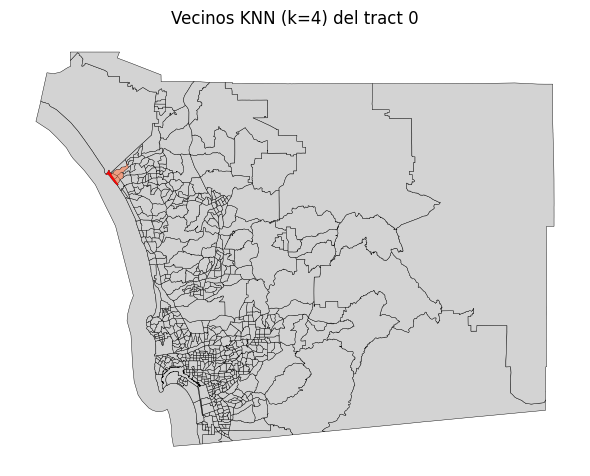

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

idx = 0  # tract de referencia
neighbors = list(wk4.neighbors[idx])

san_diego_tracts.plot(facecolor="lightgrey", edgecolor="k", linewidth=0.3, ax=ax)
san_diego_tracts.iloc[[idx]].plot(facecolor="red", ax=ax)
san_diego_tracts.iloc[neighbors].plot(facecolor="coral", alpha=0.6, ax=ax)
ax.set_axis_off()
ax.set_title(f"Vecinos KNN (k=4) del tract {idx}")

plt.tight_layout()
plt.show()

### Propiedades de KNN

- **No hay islas** por construcción: todo nodo tiene exactamente $k$ vecinos.
- **Cardinalidad uniforme**: todos los nodos tienen el mismo grado de salida ($k$).
- Sin embargo, el grafo **no es necesariamente simétrico**: que A sea vecino de B no implica que B sea vecino de A.



## 3.2 Pesos tipo kernel

Los pesos kernel implementan de forma directa la **Primera Ley de Tobler**: *todo está relacionado con todo, pero las cosas cercanas están más relacionadas que las lejanas*. El peso entre $i$ y $j$ es una función decreciente de su distancia.

Los dos parámetros principales son:
1. **Función kernel**: controla la forma de la curva de decaimiento (triangular, gaussiana, etc.).
2. **Ancho de banda (*bandwidth*)**: distancia máxima de influencia; más allá, el peso es 0.


In [27]:
# Kernel con valores por defecto (triangular, ancho de banda fijo)
w_kernel = weights.distance.Kernel.from_dataframe(gdf)




## Atributos del objeto de pesos Kernel

| Atributo | Descripción |
|---|---|
| `w_kernel.function` | Función que transforma distancias en pesos (por defecto `triangular`) |
| `w_kernel.bandwidth` | Radio de influencia de cada observación: distancia máxima hasta la que se consideran vecinos |
| `w_kernel.pct_nonzero` | Porcentaje de pares de tracts que son vecinos entre sí (densidad de la matriz de pesos) |
| `w_kernel.neighbors` | Diccionario con los vecinos de cada tract dentro del ancho de banda |
| `w_kernel.weights` | Diccionario con los pesos de cada vecino (valores entre 0 y 1, decrecen con la distancia) |

In [28]:
# Función kernel utilizada
print(f"Función kernel: {w_kernel.function}")
# Función kernel: triangular

# Ancho de banda (primeros 5 tracts)
print(f"Ancho de banda (primeros 5 valores):")
print(w_kernel.bandwidth[0:5])
# [[3321.45]
#  [3321.45]
#  [3321.45]
#  [3321.45]
#  [3321.45]]  → mismo radio para todos (ancho de banda fijo)

# Densidad de la matriz de pesos
print(f"Densidad: {w_kernel.pct_nonzero:.2f}%")
# Densidad: 40.74%  → el 40.74% de los pares son vecinos,
#                     mucho más que KNN porque el radio captura muchos tracts

# Vecinos del tract 0
print(f"Vecinos del tract 0: {w_kernel.neighbors[0]}")
# Vecinos del tract 0: [1, 5, 12, 23, 45]  → tracts dentro del ancho de banda

# Pesos del tract 0 (decrecen con la distancia)
print(f"Pesos del tract 0: {w_kernel.weights[0]}")
# Pesos del tract 0: [0.95, 0.87, 0.73, 0.61, 0.42]  → más cercano = mayor peso

Función kernel: triangular
Ancho de banda (primeros 5 valores):
[[1.0000001]
 [1.0000001]
 [1.0000001]
 [1.0000001]
 [1.0000001]]
Densidad: 40.74%
Vecinos del tract 0: [np.int64(0), np.int64(1), np.int64(3)]
Pesos del tract 0: [1.0, 9.99999900663795e-08, 9.99999900663795e-08]


## Función kernel: ¿cómo decae el peso con la distancia?

La función kernel define cómo se transforma la distancia entre dos tracts en un peso.
Si el ancho de banda es `h(bandwidth o radio maximo de influencia)` y la distancia es `d`, cada función aplica una fórmula distinta:

| Función | Fórmula | Comportamiento |
|---|---|---|
| `triangular` | `1 - (d / h)` | Decaimiento **lineal** (por defecto) |
| `uniform` | `1` si `d ≤ h` | Todos los vecinos dentro del radio tienen **peso igual** |
| `quadratic` | `(3/4)(1 - (d/h)²)` | Decaimiento **suave en parábola** (Epanechnikov) |
| `quartic` | `(15/16)(1 - (d/h)²)²` | Decaimiento más **pronunciado** que quadratic |
| `gaussian` | `e^(-d²/2h²)` | Decaimiento en **curva normal**, sin corte abrupto |

La diferencia clave es que `gaussian` no tiene un corte abrupto: todos los tracts
son vecinos pero los muy lejanos tienen peso casi 0. Las demás funciones tienen un
**radio fijo** donde más allá del ancho de banda el peso es exactamente 0.

Para cambiar la función:
```python
w_kernel_gaussian = weights.distance.Kernel.from_dataframe(
    san_diego_tracts, function="gaussian"
)
```

### Ancho de banda adaptativo

Un ancho de banda **fijo** puede ser problemático cuando la densidad de observaciones varía geográficamente: zonas densas tendrían muchos vecinos, zonas dispersas muy pocos.

La alternativa es un ancho de banda **adaptativo**: para cada observación, se selecciona un ancho de banda que incluya exactamente a sus $k$ vecinos más cercanos.


In [29]:
# Subconjunto de tracts para visualizar kernels adaptativos
sub_30 = san_diego_tracts.query("sub_30 == True")

# Kernel adaptativo con k=15
w_adaptive = weights.distance.Kernel.from_dataframe(
    sub_30, fixed=False, k=15
)

# Los anchos de banda varían por observación
print("Anchos de banda (primeros 5):")
print(w_adaptive.bandwidth[:5])


Anchos de banda (primeros 5):
[[7065.74020822]
 [3577.22591841]
 [2989.74807871]
 [2891.46196945]
 [3965.08354232]]


## Kernel adaptativo: ¿cómo se ajusta el ancho de banda?

Con `fixed=False` y `k=15`, el ancho de banda se ajusta de forma automática
para cada tract siguiendo estos pasos:

### ¿De dónde salen las distancias?

Las distancias se calculan automáticamente a partir de los **centroides** de cada
tract, es decir, el punto central de cada polígono. `from_dataframe()` hace esto
internamente sin necesidad de calcularlas manualmente.

1. **Extrae el centroide** de cada tract desde el GeoDataFrame.
2. **Calcula la distancia euclidiana** entre cada par de centroides.
3. **Ordena** esas distancias de menor a mayor.
4. Toma la distancia al **tract número k** (el k-ésimo más cercano).
5. Ese valor se convierte en el **ancho de banda** de ese tract.

Por ejemplo con `k=15`:
```
Tract A  →  centroide A  (x=1000, y=2000)
Tract B  →  centroide B  (x=1300, y=2400)

distancia(A, B) = √((1300-1000)² + (2400-2000)²) = 500m

Tract A (zona densa):
  distancias ordenadas: [120m, 150m, 180m, ..., 400m, ...]
  ancho de banda = distancia al vecino 15 = 400m

Tract B (zona dispersa):
  distancias ordenadas: [800m, 950m, 1200m, ..., 3500m, ...]
  ancho de banda = distancia al vecino 15 = 3500m
```

Por eso en zonas densas el radio es **pequeño** y en zonas dispersas es **grande**,
pero siempre garantizando que exactamente **k tracts caigan dentro del ancho de banda**.

> **Importante**: el GeoDataFrame debe estar en una **proyección métrica** (como UTM)
> y no en coordenadas geográficas (latitud/longitud). Si se usaran grados, las
> distancias no tendrían sentido geométrico real.

> **Diferencia clave con KNN**: en KNN los k vecinos tienen todos peso 1.
> En el kernel adaptativo los k vecinos tienen pesos que **decaen con la distancia**
> según la función kernel elegida (`triangular`, `gaussian`, etc.).

/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


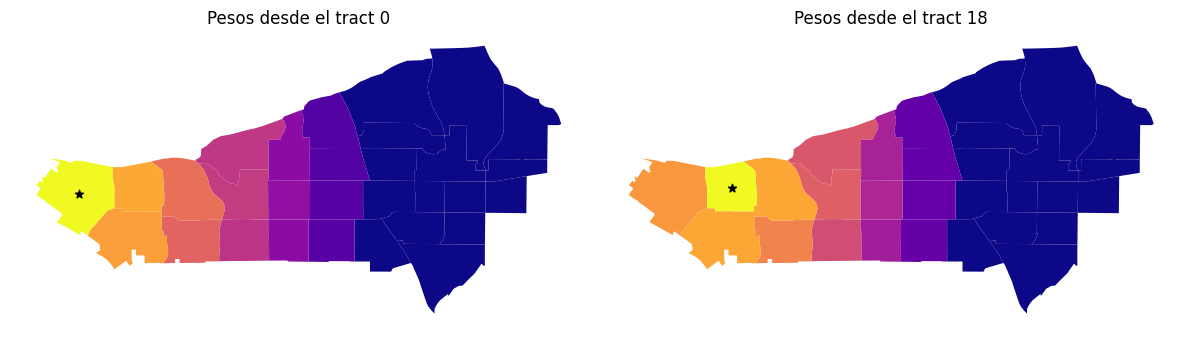

In [30]:
# Convertir pesos a matriz completa (filas = tracts, columnas = pesos hacia otros tracts)
full_matrix, ids = w_adaptive.full()

f, ax = plt.subplots(1, 2, figsize=(12, 6))

# --- Panel izquierdo: tract 0 como focal ---
# Agrega al mapa una columna con los pesos que el tract 0 le da a cada vecino
sub_30["pesos"] = full_matrix[0]  # fila 0 = pesos desde el tract 0
sub_30.plot("pesos", cmap="plasma", ax=ax[0])  # color = intensidad del peso

# Marca el tract focal con una estrella
sub_30.iloc[[0]].centroid.plot(ax=ax[0], marker="*", color="k")
ax[0].set_title("Pesos desde el tract 0")
ax[0].set_axis_off()

# --- Panel derecho: tract 18 como focal ---
sub_30["pesos"] = full_matrix[17]  # fila 17 = pesos desde el tract 18
sub_30.plot("pesos", cmap="plasma", ax=ax[1])

sub_30.iloc[[17]].centroid.plot(ax=ax[1], marker="*", color="k")
ax[1].set_title("Pesos desde el tract 18")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()


Para cada tract focal (marcado con ⭐) el mapa responde la pregunta:

> **"Si soy el tract X, ¿cuánto me importa cada uno de mis vecinos?"**

Los colores representan el peso que el tract focal le asigna a cada vecino:

| Color | Significado |
|---|---|
| Brillante | Tract cercano → peso alto |
| Oscuro | Tract lejano → peso bajo |
| Negro | Fuera del ancho de banda → peso = 0 |

Como el kernel es **adaptativo**, la "mancha de color" alrededor de cada tract
focal puede tener un tamaño distinto dependiendo de si el tract está en una zona
densa o dispersa:

- En zonas **densas** → la mancha es pequeña (radio corto).
- En zonas **dispersas** → la mancha es grande (radio largo).

Esto es precisamente la ventaja del kernel adaptativo frente al fijo: se ajusta
al contexto local de cada observación.

## 3.3 Bandas de distancia y pesos híbridos

Otra opción: trazar un **círculo de radio fijo** alrededor de cada observación y considerar como vecinos a todos los que caigan dentro del círculo (similar a un *buffer* en SIG).


In [31]:
print(san_diego_tracts.crs)

EPSG:3857


In [32]:
# Banda de distancia binaria (umbral = 1.5)
w_bdb = weights.distance.DistanceBand.from_dataframe(gdf, 1500, binary=True)

# Banda de distancia continua (inverso de la distancia)
w_hy = weights.distance.DistanceBand.from_dataframe(gdf, 1500, binary=False)


/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/scipy/sparse/_data.py:128: RuntimeWarning: divide by zero encountered in power
  return self._with_data(data ** n)


## DistanceBand: `binary=True` vs `binary=False`

`DistanceBand` define vecinos usando un **umbral fijo de distancia**. Todos los
tracts dentro del umbral son vecinos, todos los de afuera no. La diferencia entre
`binary=True` y `binary=False` está en **cómo se asignan los pesos**:

### `binary=True` → todo o nada

El peso es simplemente 1 si es vecino y 0 si no lo es:
```
distancia(A, B) = 800m  < 1500m  →  peso = 1  ✓ vecino
distancia(A, C) = 2000m > 1500m  →  peso = 0  ✗ no es vecino
```

### `binary=False` → inverso de la distancia

Los vecinos dentro del umbral reciben un peso proporcional a su cercanía:
```
distancia(A, B) = 500m   →  peso = 1/500  = 0.002  (más cercano, más peso)
distancia(A, C) = 1200m  →  peso = 1/1200 = 0.0008 (más lejano, menos peso)
distancia(A, D) = 2000m  →  peso = 0               (fuera del umbral)
```



In [33]:
# Comparar: pesos binarios vs pesos continuos para el tract 4
print("Binary - vecinos del tract 4:", w_bdb.neighbors[4])
print("Binary - pesos del tract 4:", w_bdb.weights[4])

print("\nContinuo - vecinos del tract 4:", w_hy.neighbors[4])
print("Continuo - pesos del tract 4:", w_hy.weights[4])

Binary - vecinos del tract 4: [0, 1, 2, 3, 5, 6, 7, 8]
Binary - pesos del tract 4: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Continuo - vecinos del tract 4: [0, 1, 2, 3, 5, 6, 7, 8]
Continuo - pesos del tract 4: [0.7071067811865475, 1.0, 0.7071067811865475, 1.0, 1.0, 0.7071067811865475, 1.0, 0.7071067811865475]
